In [1]:
import sys

import pyBrainAnalyzIR
import pyBrainAnalyzIR.testing.simData

from pyBrainAnalyzIR.vis.plot_nirs_inline import plot as nirs_show

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pyBrainAnalyzIR.pipelines.modules.connectivity import resting_state_connectivity
from pyBrainAnalyzIR.utils.geo_transforms import geo_rotation
import pyBrainAnalyzIR.dataclasses.dataset as dataset

# This will allow matplotlib to work as a widget (needs "pip install ipympl")
%matplotlib widget

In [2]:
data=pyBrainAnalyzIR.testing.simData.ARnoise()

In [3]:
job = resting_state_connectivity()
job.inputName = 'amp'

In [4]:
data = job.run(data)

In [5]:
data['conn'].coef

,Coeff,Pvalue,Condition,Channel_to,Channel_from,Type_to,Type_from,geo_to,geo_from
0,1.000000,1.000000e+00,rest,S1D1,S1D1,760.0,760.0,default,default
1,0.349332,7.820242e-87,rest,S2D1,S1D1,760.0,760.0,default,default
2,0.332443,2.493923e-78,rest,S2D2,S1D1,760.0,760.0,default,default
3,0.334579,2.242125e-79,rest,S3D2,S1D1,760.0,760.0,default,default
4,0.316969,5.385463e-71,rest,S3D3,S1D1,760.0,760.0,default,default
...,...,...,...,...,...,...,...,...,...
507,0.328661,1.695124e-76,rest,S7D6,S9D8,850.0,850.0,default,default
508,0.331914,4.517702e-78,rest,S7D7,S9D8,850.0,850.0,default,default
509,0.304584,1.975453e-65,rest,S8D7,S9D8,850.0,850.0,default,default
510,0.325333,6.613567e-75,rest,S8D8,S9D8,850.0,850.0,default,default


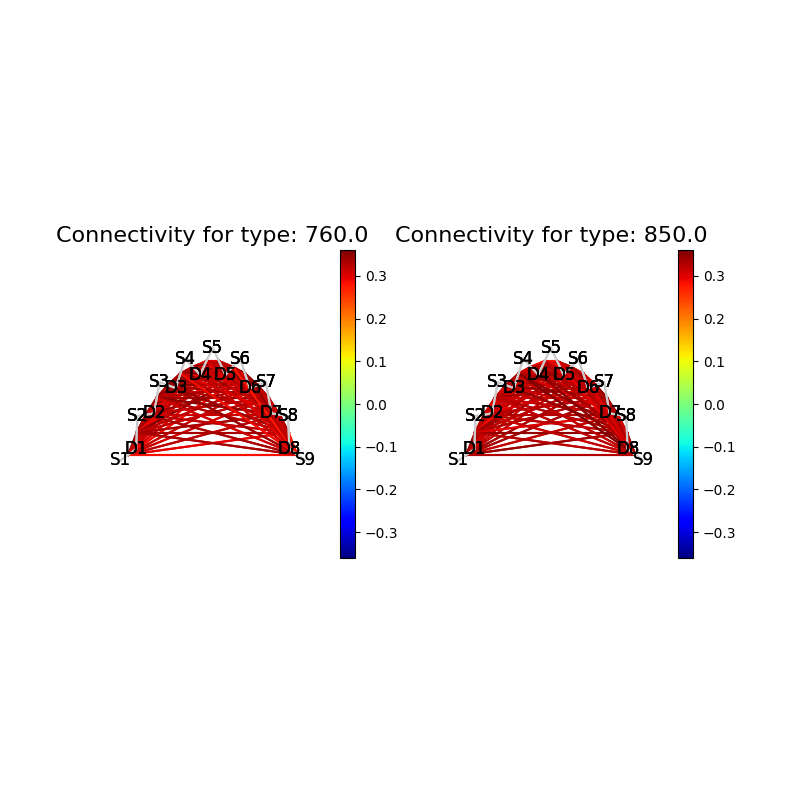

In [6]:
data['conn'].show(thres=0.0001, threshold_type='q')

In [7]:
dset=dataset.DataSet()
data1,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data2,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data3,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data4,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data5,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data6,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)

dset.import_data(data1)
dset.import_data(data2)
dset.import_data(data3)
dset.import_data(data4)
dset.import_data(data5)
dset.import_data(data6)

demo=pd.DataFrame({'subject':['A','B','C','D','E','F'],
                'pair':['dyad1','dyad1','dyad2','dyad2','dyad3','dyad3']})
dset.add_demographics_by_index(demo)


 94%|█████████▍| 15/16 [00:00<00:00, 877.19it/s]


In [8]:
from pyBrainAnalyzIR.pipelines.modules.connectivity import hyperscanning

job = hyperscanning()
job.inputName='amp'
job.options['grouping_variable']='pair'
job.options['AR']=18


In [9]:
dset=job.run(dset)

Computing connectivity for pair=dyad1
Computing connectivity for pair=dyad2
Computing connectivity for pair=dyad3


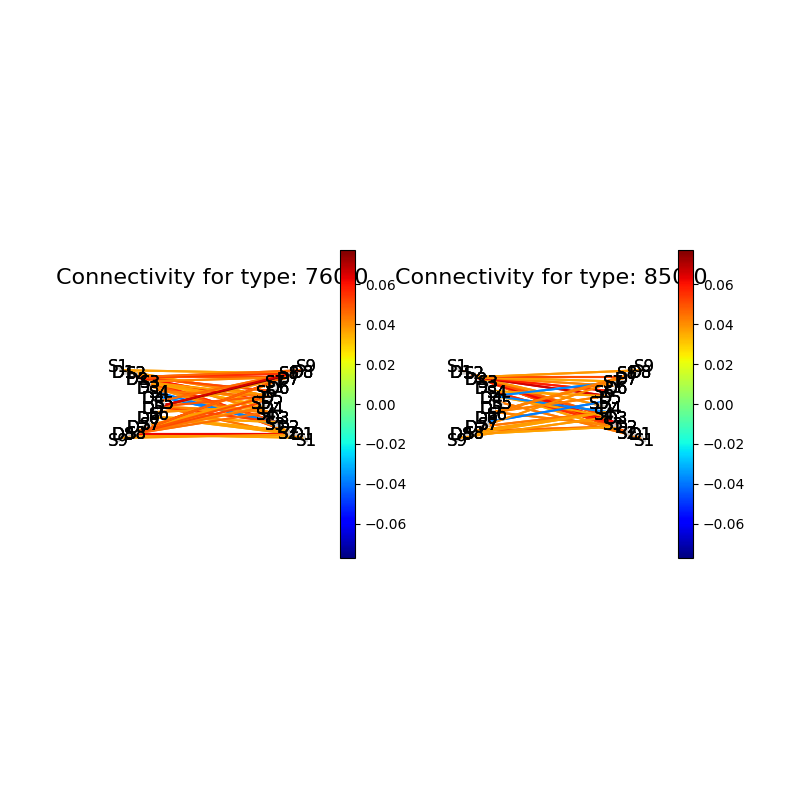

In [10]:

conn=dset.dataset[0]['hyperconn']
conn.show(thres=0.05, threshold_type='p')


In [11]:
job.options['unordered']=True
dset=job.run(dset)

Computing connectivity for pair=dyad1
Computing connectivity for pair=dyad2
Computing connectivity for pair=dyad3


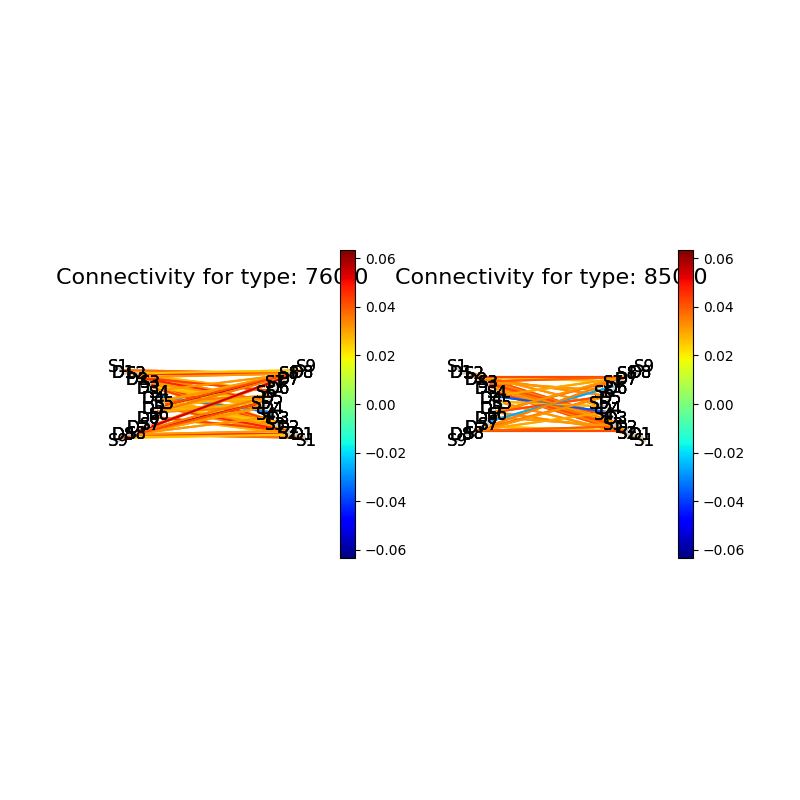

In [14]:
conn=dset.dataset[0]['hyperconn']
conn.show(thres=0.05, threshold_type='p')